# IV.3.1.2 — Hand Scale Variation Across Signers

This notebook measures and quantifies **inter-signer hand scale variation** in the raw BISINDO skeleton data.

Hand scale is represented by the **wrist–middle fingertip distance** per frame, following Amprimo et al. (2024).

Two visualizations:
1. **Fig B** — Annotated boxplot of hand scale distribution per signer (full dataset, both hands)
2. **Kruskal–Wallis test** — Statistical verification that inter-signer scale differences are significant

---

In [10]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from collections import defaultdict
from scipy import stats
import os

# ── Paper-style global rcParams (consistent with reference notebooks) ─────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_LH     = '#2166AC'   # Left hand  – deep blue
C_RH     = '#D6604D'   # Right hand – muted red
C_EDGE   = '#555555'   # Skeleton edges
C_NOISE  = '#B2182B'   # Noise highlight – red
C_VALID  = '#4393C3'   # Valid keypoint
GRAYS    = ['#1a1a1a', '#555555', '#888888', '#bbbbbb']
BAR_EC   = 'black'
BAR_LW   = 0.6

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hand keypoint indices ──────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

IDX_LH   = np.arange(0, 21)    # Left hand
IDX_RH   = np.arange(21, 42)   # Right hand
IDX_HAND = np.arange(0, 42)    # Both hands

# ── Wrist–Middle Fingertip keypoint indices ────────────────────────────────────
# MediaPipe Hand: keypoint 0 = wrist, keypoint 12 = middle fingertip
IDX_LH_WRIST  = 0    # Left wrist
IDX_LH_MFT    = 12   # Left middle fingertip
IDX_RH_WRIST  = 21   # Right wrist  (offset +21 in full 42-kp array)
IDX_RH_MFT    = 33   # Right middle fingertip (12 + 21)

print('Configuration loaded.')


Configuration loaded.


## 0. Load Data

In [11]:
# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:5]}')

# Extract signer info from video ID (format: Pxx_Sxxx_Rxx)
speakers = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  (21 pts)
# [21:42] = Right Hand (21 pts)
# [42:61] = Mouth      (19 pts)
# [61:86] = Pose/Body  (25 pts)
K_TOTAL = 86


Total videos : 807
Sample IDs   : ['P1_S01_R1', 'P1_S01_R2', 'P1_S01_R3', 'P1_S01_R4', 'P1_S01_R5']
Signers      : ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']


---
## IV.3.1.2 — Hand Scale Variation Across Signers

**Fig B** — Annotated boxplot of wrist–middle fingertip distance per signer.

Each data point = one frame-level distance value (all valid frames, all videos, all sentences).  
Median value is annotated in red above each box.  
Max inter-signer spread and Kruskal–Wallis result are reported per panel.

── Ringkasan Ukuran Tangan per Penutur ──
 Penutur  Median Kiri   IQR Kiri  Median Kanan  IQR Kanan
      P1       0.1073     0.0823        0.1245     0.1011
      P2       0.1285     0.0512        0.1324     0.0941
      P3       0.0919     0.0870        0.1005     0.0763
      P4       0.1176     0.1020        0.1096     0.0986
      P5       0.0931     0.0832        0.0996     0.0772
      P6       0.0995     0.0676        0.0990     0.0790


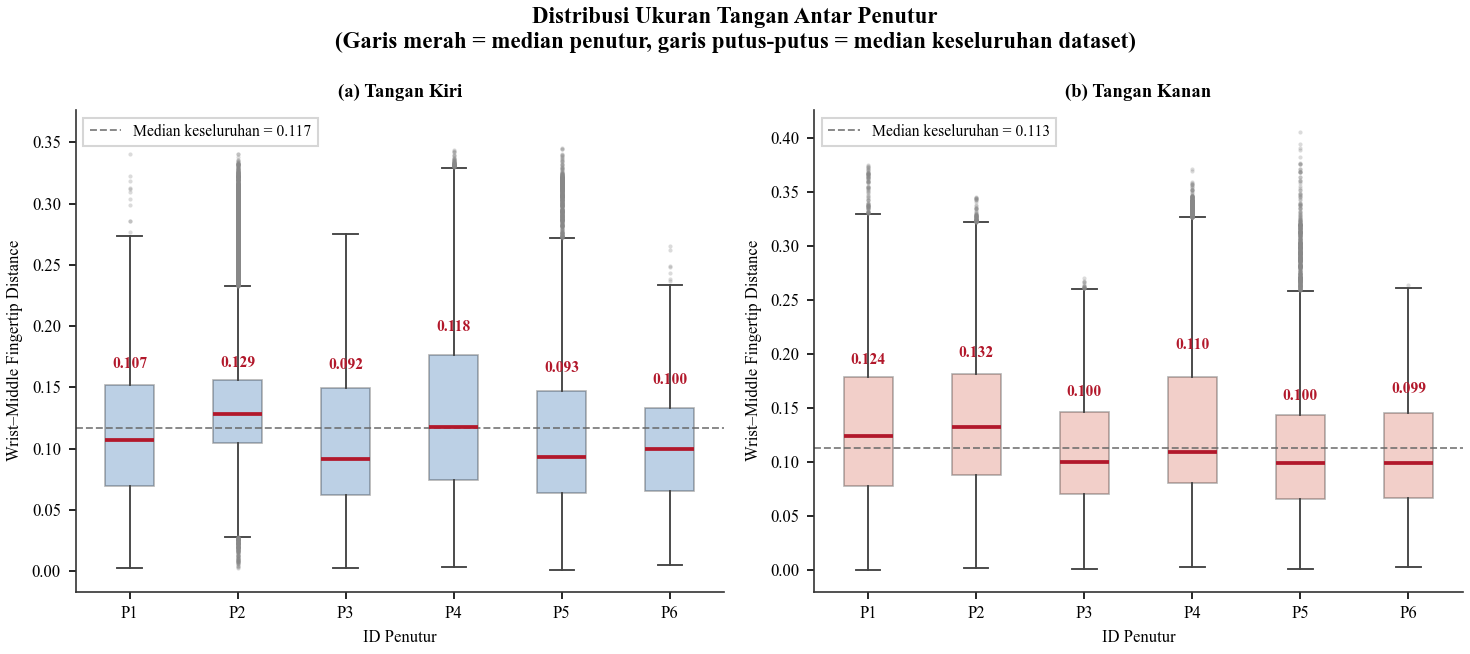

[SAVED] ../data/results\spatial_B_hand_scale_boxplot.png


In [12]:
# ── Gambar B: Distribusi Ukuran Tangan Antar Penutur ──────────────────────────
# Ukuran tangan dihitung sebagai jarak antara pergelangan tangan
# dan ujung jari tengah pada setiap frame valid.

# ── Kumpulkan data jarak per frame untuk setiap penutur ──────────────────────
scale_data = {sp: {'lh': [], 'rh': []} for sp in speakers}

for vid, val in data.items():

    sp = vid.split('_')[0]

    if sp not in scale_data:
        continue

    kp = val['keypoints']

    # ── Tangan kiri ────────────────────────────────────────────────────────────
    lh_wrist = kp[:, IDX_LH_WRIST, :]
    lh_tip   = kp[:, IDX_LH_MFT, :]

    valid_lh = (
        ~((lh_wrist[:, 0] == 0) & (lh_wrist[:, 1] == 0)) &
        ~((lh_tip[:, 0]   == 0) & (lh_tip[:, 1]   == 0))
    )

    if valid_lh.sum() > 0:
        dist_lh = np.linalg.norm(
            lh_tip[valid_lh] - lh_wrist[valid_lh],
            axis=1
        )
        scale_data[sp]['lh'].extend(dist_lh.tolist())

    # ── Tangan kanan ───────────────────────────────────────────────────────────
    rh_wrist = kp[:, IDX_RH_WRIST, :]
    rh_tip   = kp[:, IDX_RH_MFT, :]

    valid_rh = (
        ~((rh_wrist[:, 0] == 0) & (rh_wrist[:, 1] == 0)) &
        ~((rh_tip[:, 0]   == 0) & (rh_tip[:, 1]   == 0))
    )

    if valid_rh.sum() > 0:
        dist_rh = np.linalg.norm(
            rh_tip[valid_rh] - rh_wrist[valid_rh],
            axis=1
        )
        scale_data[sp]['rh'].extend(dist_rh.tolist())

# ── Ringkasan statistik ───────────────────────────────────────────────────────
print('── Ringkasan Ukuran Tangan per Penutur ──')
print(f'{"Penutur":>8} {"Median Kiri":>12} {"IQR Kiri":>10} {"Median Kanan":>13} {"IQR Kanan":>10}')

for sp in speakers:

    lh = np.array(scale_data[sp]['lh'])
    rh = np.array(scale_data[sp]['rh'])

    iqr_lh = np.percentile(lh, 75) - np.percentile(lh, 25)
    iqr_rh = np.percentile(rh, 75) - np.percentile(rh, 25)

    print(
        f'{sp:>8} '
        f'{np.median(lh):>12.4f} '
        f'{iqr_lh:>10.4f} '
        f'{np.median(rh):>13.4f} '
        f'{iqr_rh:>10.4f}'
    )

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, (ax_lh, ax_rh) = plt.subplots(
    1, 2,
    figsize=(10, 4.5),
    dpi=150
)

panel_cfg = [
    (ax_lh, 'lh', '(a) Tangan Kiri', C_LH),
    (ax_rh, 'rh', '(b) Tangan Kanan', C_RH),
]

for ax, hand_key, title, base_color in panel_cfg:

    box_data = [scale_data[sp][hand_key] for sp in speakers]

    medians = [
        np.median(d)
        for d in box_data
    ]

    median_dataset = np.median(
        [v for grp in box_data for v in grp]
    )

    bp = ax.boxplot(
        box_data,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(
            color='#B2182B',
            linewidth=1.8
        ),
        whiskerprops=dict(
            color='#444444',
            linewidth=0.9
        ),
        capprops=dict(
            color='#444444',
            linewidth=0.9
        ),
        flierprops=dict(
            marker='o',
            markersize=2,
            markerfacecolor='#888888',
            markeredgewidth=0,
            alpha=0.30
        ),
        boxprops=dict(
            linewidth=0.8
        )
    )

    for patch in bp['boxes']:
        patch.set_facecolor(base_color)
        patch.set_alpha(0.30)

    # Median setiap penutur
    for i, (med, grp) in enumerate(zip(medians, box_data), start=1):

        ax.text(
            i,
            np.percentile(grp, 80),
            f'{med:.3f}',
            ha='center',
            va='bottom',
            fontsize=7.5,
            color='#B2182B',
            fontweight='bold'
        )

    # Median keseluruhan dataset
    ax.axhline(
        median_dataset,
        color='#666666',
        linewidth=0.9,
        linestyle='--',
        alpha=0.8,
        label=f'Median keseluruhan = {median_dataset:.3f}'
    )

    # Rentang median antar penutur
    rentang = max(medians) - min(medians)

    ax.set_title(
        title,
        fontsize=9,
        fontweight='bold'
    )

    ax.set_xticks(
        range(1, len(speakers) + 1)
    )

    ax.set_xticklabels(
        speakers
    )

    ax.set_xlabel(
        'ID Penutur',
        fontsize=8
    )

    ax.set_ylabel(
        'Wrist–Middle Fingertip Distance',
        fontsize=8
    )

    ax.legend(
        fontsize=7.5,
        frameon=True,
        framealpha=0.8,
        edgecolor='#CCCCCC',
        fancybox=False,
        loc='upper left'
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'Distribusi Ukuran Tangan Antar Penutur\n'
    '(Garis merah = median penutur, garis putus-putus = median keseluruhan dataset)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_B_hand_scale_boxplot.png'
)

plt.savefig(
    save_path,
    bbox_inches='tight'
)

plt.show()

print(f'[SAVED] {save_path}')